<a href="https://colab.research.google.com/github/nkumari8-star/weather_model_quadratic/blob/main/leNet_deeplearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
The size of train_x is: (60000, 28, 28)
The size of train_y is: (60000,)
The size of test_x is: (10000, 28, 28)
The size of test_y is: (10000,)
[[0. 0. 0. ... 1. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

469/469 ━━━━━━━━━━━━━━━━━━━━ 30s 59ms/step - accuracy: 0.9033 - loss: 0.3422 - val_accuracy: 0.9567 - val_loss: 0.1500


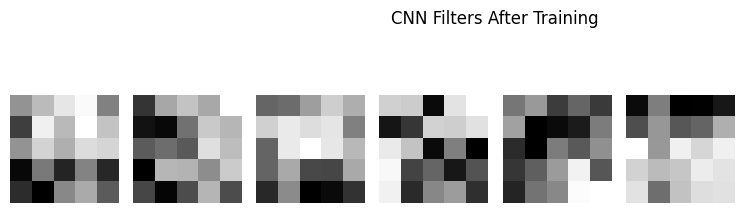

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9567 - loss: 0.1500
Test Loss: 0.15001280605793
Test accuracy: 0.9567000269889832


In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AvgPool2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical, plot_model
import matplotlib.pyplot as plt

# Loading the dataset and performing splitting¶
(train_x, train_y), (test_x, test_y) = mnist.load_data()

#Checking the sizes of train and test split
print("The size of train_x is: {}".format(train_x.shape))
print("The size of train_y is: {}".format(train_y.shape))

print("The size of test_x is: {}".format(test_x.shape))
print("The size of test_y is: {}".format(test_y.shape))


# Peforming reshaping operations- Converting into 4-D¶

train_x = train_x.reshape(train_x.shape[0], 28, 28, 1)
test_x = test_x.reshape(test_x.shape[0], 28, 28, 1)


# Normalizing the values of image- converting in between 0 and 1¶
train_x = train_x/255.0
test_x = test_x/255.0


# One-hot encoding the labels
train_y = to_categorical(train_y, num_classes=10)

test_y = to_categorical(test_y, num_classes=10)
print(test_y)


# Building the Model Architecture¶


model = Sequential()

model.add(Conv2D(filters=6,
                 kernel_size=(5,5),
                 padding='valid',
                 input_shape=(28,28,1),
                 activation='tanh'))
model.add(AvgPool2D(pool_size=(2,2)))
model.add(Conv2D(filters=16,
                 kernel_size=(5,5),
                 padding='valid',
                 activation='tanh'))
model.add(AvgPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(120, activation='tanh'))
model.add(Dense(84, activation='tanh'))
model.add(Dense(10, activation='softmax'))
model.summary()

# Compiling the model
model.compile(loss='categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])

# Fitting the model
model.fit(train_x, train_y, batch_size=128, epochs=1, verbose=1, validation_data=(test_x, test_y))


conv_layer = model.layers[0]
filters = conv_layer.get_weights()[0]

plt.figure(figsize=(10, 10))
for i in range(6):
    plt.subplot(4, 8, i+1)
    plt.imshow(filters[:, :, 0, i], cmap='gray')
    plt.axis('off')
plt.suptitle('CNN Filters After Training')
plt.tight_layout()
plt.show()


#Finding the loss and accuracy of the model
score = model.evaluate(test_x, test_y)

print('Test Loss:', score[0])
print('Test accuracy:', score[1])


In [2]:
# Import the necessary Libraries
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical, plot_model


## Loading the dataset and performing splitting

(train_x, train_y), (test_x, test_y) = mnist.load_data()


## Checking the sizes of train and test split

print("The size of train_x is: {}".format(train_x.shape))
print("The size of train_y is: {}".format(train_y.shape))

print("The size of test_x is: {}".format(test_x.shape))
print("The size of test_y is: {}".format(test_y.shape))


## Peforming reshaping operations- Converting into 4-D


train_x = train_x.reshape(train_x.shape[0], 28, 28, 1)
test_x = test_x.reshape(test_x.shape[0], 28, 28, 1)




## Normalizing the values of image- converting in between 0 and 1
train_x = train_x/255.0
test_x = test_x/255.0


## One-hot encoding the labels

train_y = to_categorical(train_y, num_classes=10)
test_y = to_categorical(test_y, num_classes=10)

# VGG-model for 28x28 MNIST
model = Sequential()

# Block 1: 28x28 -> 14x14
model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28, 28, 1)))
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2,2), strides=2))

# Block 2: 14x14 -> 7x7
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2,2), strides=2))

# Block 3: 7x7 -> 3x3
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2,2), strides=2))

# Flatten and Optimized FC layers
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(10, activation='softmax')) # 10 classes for MNIST

model.summary()

## Compiling the model
model.compile(loss='categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])


## Fitting the model
model.fit(train_x, train_y, batch_size=128, epochs=1, verbose=1, validation_data=(test_x, test_y))


## Finding the loss and accuracy of the model
score = model.evaluate(test_x, test_y)

print('Test Loss:', score[0])
print('Test accuracy:', score[1])


The size of train_x is: (60000, 28, 28)
The size of train_y is: (60000,)
The size of test_x is: (10000, 28, 28)
The size of test_y is: (10000,)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 584,170 (2.23 MB)

 Trainable params: 584,170 (2.23 MB)

 Non-trainable params: 0 (0.00 B)

469/469 ━━━━━━━━━━━━━━━━━━━━ 375s 793ms/step - accuracy: 0.9449 - loss: 0.1695 - val_accuracy: 0.9868 - val_loss: 0.0419
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.9868 - loss: 0.0419
Test Loss: 0.0418677031993866
Test accuracy: 0.9868000149726868


In [3]:
# Import the necessary Libraries
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical, plot_model


## Loading the dataset and performing splitting

(train_x, train_y), (test_x, test_y) = mnist.load_data()


## Checking the sizes of train and test split

print("The size of train_x is: {}".format(train_x.shape))
print("The size of train_y is: {}".format(train_y.shape))

print("The size of test_x is: {}".format(test_x.shape))
print("The size of test_y is: {}".format(test_y.shape))


## Peforming reshaping operations- Converting into 4-D


train_x = train_x.reshape(train_x.shape[0], 28, 28, 1)
test_x = test_x.reshape(test_x.shape[0], 28, 28, 1)




## Normalizing the values of image- converting in between 0 and 1
train_x = train_x/255.0
test_x = test_x/255.0


## One-hot encoding the labels

train_y = to_categorical(train_y, num_classes=10)
test_y = to_categorical(test_y, num_classes=10)


## The Model
model = Sequential()

model.add(Conv2D(96, (5,5), strides=4, padding='valid',
                 input_shape=(28,28,1), activation='relu'))

model.add(MaxPool2D((2,2), strides=2))

model.add(Conv2D(256, (3,3), padding='same', activation='relu'))

model.add(MaxPool2D((2,2), strides=1))

model.add(Conv2D(384, (1,1), padding='same', activation='relu'))

model.add(Conv2D(384, (1,1), padding='same', activation='relu'))

model.add(Conv2D(256, (1,1), padding='same', activation='relu'))

model.add(Flatten())

model.add(Dense(512, activation='relu'))

model.add(Dense(512, activation='relu'))

model.add(Dense(10, activation='softmax'))
model.summary()


## Compiling the model
model.compile(loss='categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])


## Fitting the model
model.fit(train_x, train_y, batch_size=128, epochs=1, verbose=1, validation_data=(test_x, test_y))


## Finding the loss and accuracy of the model
score = model.evaluate(test_x, test_y)

print('Test Loss:', score[0])
print('Test accuracy:', score[1])

The size of train_x is: (60000, 28, 28)
The size of train_y is: (60000,)
The size of test_x is: (10000, 28, 28)
The size of test_y is: (10000,)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 96)       │         2,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 3, 3, 256)      │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 2, 2, 384)      │        98,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 2, 2, 384)      │       147,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 2, 2, 256)      │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,361,610 (5.19 MB)

 Trainable params: 1,361,610 (5.19 MB)

 Non-trainable params: 0 (0.00 B)

469/469 ━━━━━━━━━━━━━━━━━━━━ 88s 181ms/step - accuracy: 0.8787 - loss: 0.3590 - val_accuracy: 0.9627 - val_loss: 0.1194
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9627 - loss: 0.1194
Test Loss: 0.11937133967876434
Test accuracy: 0.9627000093460083
